In [3]:
import os
from scanpy import read_h5ad

output_dir = 'Intermediate_Files/Clustering_07282025'
adata_i_filtered = read_h5ad(os.path.join(output_dir, "PBMC_iso_AutoZI_clustered_celltypes_reannotated_AutoZILatent_08132025.h5mu"))

labels = adata_i_filtered.obs["sub_cell_type"].copy()
labels.index = labels.index.astype(str)

In [2]:
print(adata_i_filtered)

AnnData object with n_obs × n_vars = 33018 × 87279
    obs: 'sample', 'n_isoforms_by_counts', 'log1p_n_genes_by_counts', 'total_counts_isoforms', 'log1p_total_counts_isoforms', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet', 'predicted_doublet_auto', 'predicted_doublet_final', 'batch', '_scvi_batch', '_scvi_labels', '0.04_log_AutoZI', '0.06_log_AutoZI', '0.1_log_AutoZI', '0.14_log_AutoZI', '0.16_log_AutoZI', '0.2_log_AutoZI', '0.24_log_AutoZI', '0.26_log_AutoZI', '0.3_log_AutoZI', '0.34_log_AutoZI', '0.36_log_AutoZI', '0.4_log_AutoZI', '0.44_log_AutoZI', '0.46_log_AutoZI', '0.5_log_AutoZI', '0.54_log_AutoZI', '0.56_log_AutoZI', '0.6_log_AutoZI', '0.64_log_AutoZI', '0.66_log_AutoZI', '0.7_log_AutoZI', '0.74_log_AutoZI', '0.76_log_AutoZI', '0.8_log_AutoZI', '0.84_log_AutoZI', '0.86_log_AutoZI', '0.9_log_AutoZI', '0.94_log_AutoZI', '0.96_log_AutoZI', '1.0_log_AutoZI', 'CD3D_pred

In [4]:
import os
import anndata as ad
import pandas as pd

Int_folder = "Intermediate_Files/QC_07232025"

PBMC1_post = ad.read_h5ad(os.path.join(Int_folder, "PBMC1_Iso_Data_Filtered_PostScrublet.h5ad"))
PBMC2_post = ad.read_h5ad(os.path.join(Int_folder, "PBMC2_Iso_Data_Filtered_PostScrublet.h5ad"))

adata_post = ad.concat(
    [PBMC1_post, PBMC2_post],
    join="inner",
    merge="same",
    label="batch",
    keys=["PBMC1", "PBMC2"]
)
adata_post.obs_names = adata_post.obs_names.astype(str)

In [9]:
adata_post.obs["sub_cell_type"] = adata_post.obs_names.map(labels)

print("Missing labels:", adata_post.obs["sub_cell_type"].isna().sum())
print("Example missing barcodes:", adata_post.obs_names[adata_post.obs["sub_cell_type"].isna()][:5].tolist())

Missing labels: 2948
Example missing barcodes: ['PBMC1_CAAGACTCCCCTCACT_filtered_mapq_10', 'PBMC1_CCTCATCGAGGTAGCA_filtered_mapq_10', 'PBMC1_ATCAAACACAATAACA_filtered_mapq_10', 'PBMC1_CCCGCATGAAAGCAAC_filtered_mapq_10', 'PBMC1_ACGTAAACCAGACACG_filtered_mapq_10']


In [5]:
import pandas as pd
import numpy as np

# Compare the datasets
print("="*60)
print("DATASET COMPARISON")
print("="*60)

print(f"\nadata_i_filtered:")
print(f"  N cells: {adata_i_filtered.n_obs}")
print(f"  N genes: {adata_i_filtered.n_vars}")
print(f"  Sample barcodes: {adata_i_filtered.obs_names[:3].tolist()}")

print(f"\nadata_post:")
print(f"  N cells: {adata_post.n_obs}")
print(f"  N genes: {adata_post.n_vars}")
print(f"  Sample barcodes: {adata_post.obs_names[:3].tolist()}")

# Check overlap
filtered_bc = set(adata_i_filtered.obs_names.astype(str))
post_bc = set(adata_post.obs_names.astype(str))

overlap = filtered_bc & post_bc
only_filtered = filtered_bc - post_bc
only_post = post_bc - filtered_bc

print(f"\n{'='*60}")
print("BARCODE OVERLAP")
print("="*60)
print(f"In both datasets: {len(overlap)}")
print(f"Only in adata_i_filtered: {len(only_filtered)}")
print(f"Only in adata_post: {len(only_post)}")

if only_filtered:
    print(f"\nExample barcodes only in filtered: {list(only_filtered)[:3]}")
if only_post:
    print(f"Example barcodes only in post: {list(only_post)[:3]}")

# Check if unlabeled = only_post
unlabeled_bc = set(adata_post.obs_names[adata_post.obs["sub_cell_type"].isna()].astype(str))
print(f"\n{'='*60}")
print("UNLABELED CELLS")
print("="*60)
print(f"Unlabeled cells: {len(unlabeled_bc)}")
print(f"Cells only in post: {len(only_post)}")
print(f"Are they the same? {unlabeled_bc == only_post}")

# If not the same, what's the overlap?
if unlabeled_bc != only_post:
    unlabeled_and_only_post = unlabeled_bc & only_post
    unlabeled_but_in_filtered = unlabeled_bc & filtered_bc
    print(f"\nUnlabeled that are only_in_post: {len(unlabeled_and_only_post)}")
    print(f"Unlabeled that ARE in filtered: {len(unlabeled_but_in_filtered)}")
    
    if unlabeled_but_in_filtered:
        print("\nWARNING: Some cells are in adata_i_filtered but didn't get labels!")
        print("This suggests a barcode format mismatch.")
        example_unlabeled_in_filtered = list(unlabeled_but_in_filtered)[:3]
        print(f"Examples from adata_post: {example_unlabeled_in_filtered}")
        
        # Check if these exist in adata_i_filtered with different format
        for bc in example_unlabeled_in_filtered:
            if bc in adata_i_filtered.obs_names:
                print(f"  {bc} -> exists in filtered, has label: {adata_i_filtered.obs.loc[bc, 'sub_cell_type']}")

DATASET COMPARISON

adata_i_filtered:
  N cells: 33018
  N genes: 87279
  Sample barcodes: ['PBMC1_ACTCAGCTAGGCCACA_filtered_mapq_10', 'PBMC1_CACTAACAATAACAAG_filtered_mapq_10', 'PBMC1_AGCAACGGAAGGCCAT_filtered_mapq_10']

adata_post:
  N cells: 35626
  N genes: 88653
  Sample barcodes: ['PBMC1_ACTCAGCTAGGCCACA_filtered_mapq_10', 'PBMC1_CAAGACTCCCCTCACT_filtered_mapq_10', 'PBMC1_CACTAACAATAACAAG_filtered_mapq_10']

BARCODE OVERLAP
In both datasets: 32678
Only in adata_i_filtered: 340
Only in adata_post: 2948

Example barcodes only in filtered: ['PBMC2_ACTCAGCGCAGGAGCT_filtered_mapq_10', 'PBMC1_AACAACGACCTAAAAG_filtered_mapq_10', 'PBMC2_CAGGAGACATATATAG_filtered_mapq_10']
Example barcodes only in post: ['PBMC2_AATTCCAGAGCTATAG_filtered_mapq_10', 'PBMC2_AGTTACCAATTCAGCC_filtered_mapq_10', 'PBMC2_ATTTACCTCCAGAGTC_filtered_mapq_10']

UNLABELED CELLS
Unlabeled cells: 2948
Cells only in post: 2948
Are they the same? True


In [5]:
#Load data with only very low filtering

PBMC1_unf = ad.read_h5ad(os.path.join(Int_folder, "PBMC1_iso_AnnData.h5ad"))
PBMC2_unf = ad.read_h5ad(os.path.join(Int_folder, "PBMC2_iso_AnnData.h5ad"))
adata_unf = ad.concat(
    [PBMC1_unf, PBMC2_unf],
    join="inner",
    merge="same",
    label="batch",
    keys=["PBMC1", "PBMC2"]
)
adata_unf.obs_names = adata_unf.obs_names.astype(str)

In [7]:
print(adata_unf)

AnnData object with n_obs × n_vars = 77219 × 102510
    obs: 'batch'


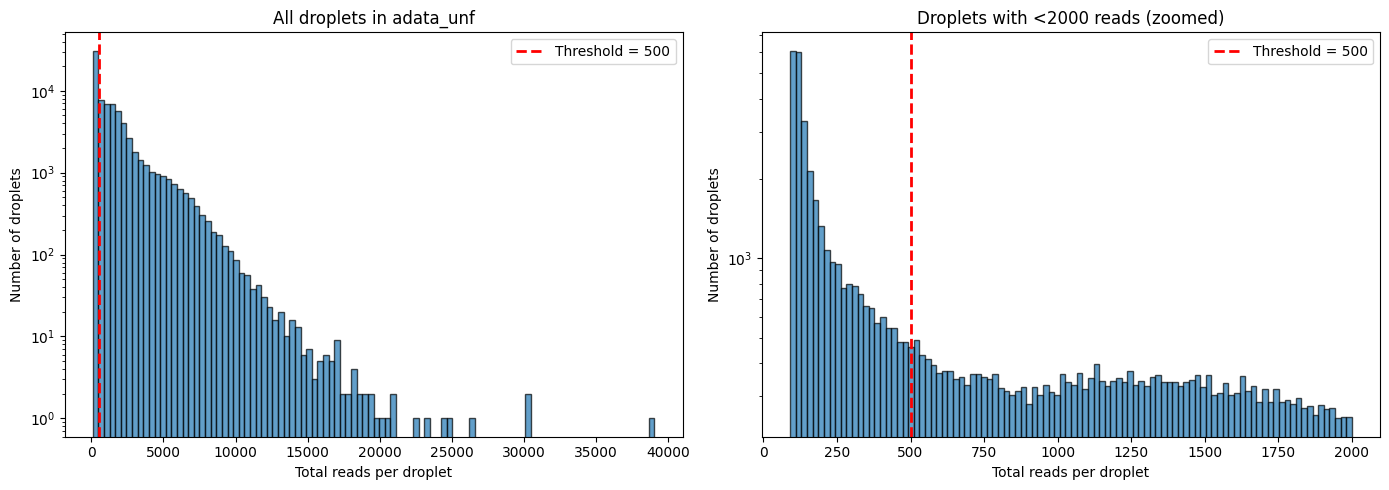

Read count quantiles in adata_unf:
  1th percentile: 101 reads (766 droplets)
  5th percentile: 106 reads (3,857 droplets)
  10th percentile: 114 reads (7,716 droplets)
  25th percentile: 188 reads (19,305 droplets)
  50th percentile: 879 reads (38,609 droplets)


In [8]:
# Visualize droplet distribution
import matplotlib.pyplot as plt

X_unf = adata_unf.X if adata_unf.X is not None else adata_unf.layers.get('counts')
totals_unf = np.asarray(X_unf.sum(axis=1)).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(totals_unf, bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(500, color='red', linestyle='--', linewidth=2, label='Threshold = 500')
axes[0].set_xlabel('Total reads per droplet')
axes[0].set_ylabel('Number of droplets')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].set_title('All droplets in adata_unf')

# Zoomed to low-count region
axes[1].hist(totals_unf[totals_unf < 2000], bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(500, color='red', linestyle='--', linewidth=2, label='Threshold = 500')
axes[1].set_xlabel('Total reads per droplet')
axes[1].set_ylabel('Number of droplets')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('Droplets with <2000 reads (zoomed)')

plt.tight_layout()
plt.savefig('empty_droplet_threshold_selection.pdf')
plt.show()

# Print quantiles
print("Read count quantiles in adata_unf:")
for pct in [1, 5, 10, 25, 50]:
    val = np.percentile(totals_unf, pct)
    count = (totals_unf < val).sum()
    print(f"  {pct}th percentile: {val:.0f} reads ({count:,} droplets)")

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.io import mmwrite

def _to_csc(x):
    return x.tocsc() if sp.issparse(x) else sp.csc_matrix(x)

def export_for_soupx(
    adata_cells,              # adata_i_filtered - high-quality cells with labels
    adata_all_droplets,       # adata_unf - all droplets including empties
    out_dir,
    counts_layer_cells="counts",
    counts_layer_droplets=None,  # None = use .X
    cluster_key="sub_cell_type",
    empty_threshold=500,      # Droplets below this are "empty"
):
    """
    SoupX export following documentation:
    - toc (table of counts) = filtered cells only
    - tod (table of droplets) = empty droplets OR all droplets
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    
    # === TOC: Filtered cells ===
    if counts_layer_cells in adata_cells.layers:
        X_cells = adata_cells.layers[counts_layer_cells]
    else:
        X_cells = adata_cells.X
    X_cells = _to_csc(X_cells)  # cells × genes
    
    # === TOD: All droplets (cells + empties) ===
    if counts_layer_droplets and counts_layer_droplets in adata_all_droplets.layers:
        X_all = adata_all_droplets.layers[counts_layer_droplets]
    else:
        X_all = adata_all_droplets.X
    
    X_all = X_all.tocsr() if sp.issparse(X_all) else np.asarray(X_all)
    totals = np.asarray(X_all.sum(axis=1)).ravel()
    
    # Identify empty droplets
    empty_mask = totals < empty_threshold
    n_empties = empty_mask.sum()
    
    print(f"\nDroplet distribution:")
    print(f"  Total droplets in adata_all_droplets: {adata_all_droplets.n_obs:,}")
    print(f"  Empty droplets (reads < {empty_threshold}): {n_empties:,}")
    print(f"  Median reads (empties): {np.median(totals[empty_mask]):.0f}")
    print(f"  Median reads (all): {np.median(totals):.0f}")
    
    if n_empties < 100:
        raise ValueError(
            f"Only {n_empties} empty droplets found with threshold={empty_threshold}. "
            f"SoupX needs sufficient empty droplets to estimate soup. "
            f"Try increasing empty_threshold or check your data."
        )
    
    # Feature alignment: ensure tod has same genes as toc (in same order)
    cells_features = pd.Index(adata_cells.var_names.astype(str))
    all_features = pd.Index(adata_all_droplets.var_names.astype(str))
    
    col_order = all_features.get_indexer(cells_features)
    
    if (col_order < 0).any():
        missing = cells_features[col_order < 0][:5].tolist()
        raise ValueError(
            f"adata_all_droplets missing genes present in adata_cells. "
            f"Examples: {missing}. Check that both datasets have same gene set."
        )
    
    # Create matrices: SoupX expects genes × barcodes
    toc = X_cells.T  # genes × cells
    tod = _to_csc(X_all[empty_mask, :][:, col_order]).T  # genes × empties
    
    print(f"\nMatrix dimensions:")
    print(f"  toc: {toc.shape[0]} genes × {toc.shape[1]} cells")
    print(f"  tod: {tod.shape[0]} genes × {tod.shape[1]} empties")
    
    # Write matrices
    mmwrite(out_dir / "toc.mtx", toc)
    mmwrite(out_dir / "tod.mtx", tod)
    
    # Write gene and barcode lists
    genes = cells_features.to_numpy()
    cell_barcodes = adata_cells.obs_names.astype(str).to_numpy()
    empty_barcodes = adata_all_droplets.obs_names[empty_mask].astype(str).to_numpy()
    
    pd.Series(genes).to_csv(out_dir / "genes.tsv", sep="\t", header=False, index=False)
    pd.Series(cell_barcodes).to_csv(out_dir / "barcodes.tsv", sep="\t", header=False, index=False)
    pd.Series(empty_barcodes).to_csv(out_dir / "ambient_barcodes.tsv", sep="\t", header=False, index=False)
    
    # Write clusters
    if cluster_key not in adata_cells.obs:
        raise KeyError(f"{cluster_key} not found in adata_cells.obs")
    
    if adata_cells.obs[cluster_key].isna().any():
        n_missing = adata_cells.obs[cluster_key].isna().sum()
        raise ValueError(
            f"{cluster_key} has {n_missing} missing labels in adata_cells.obs. "
            f"All cells must have cluster labels for SoupX."
        )
    
    clusters_df = pd.DataFrame({
        "barcode": cell_barcodes,
        "cluster": adata_cells.obs[cluster_key].astype(str).to_numpy()
    })
    clusters_df.to_csv(out_dir / "clusters.csv", index=False)
    
    print(f"\nExported SoupX inputs to: {out_dir}")
    
    return {
        "out_dir": str(out_dir),
        "n_cells": len(cell_barcodes),
        "n_empties": len(empty_barcodes),
        "empty_threshold": empty_threshold,
        "empty_mask": empty_mask  # Return this for diagnostics if needed
    }

In [7]:
import subprocess

cmd = [
    "Rscript", "-e",
    'cat("SoupX:", as.character(packageVersion("SoupX")), "\\n");'
    'cat("Matrix:", as.character(packageVersion("Matrix")), "\\n")'
]

subprocess.run(cmd)

SoupX: 1.6.2 
Matrix: 1.7.2 


CompletedProcess(args=['Rscript', '-e', 'cat("SoupX:", as.character(packageVersion("SoupX")), "\\n");cat("Matrix:", as.character(packageVersion("Matrix")), "\\n")'], returncode=0)

In [10]:
adata_post.obs["sub_cell_type"] = (
    adata_post.obs["sub_cell_type"]
    .astype("object")
    .fillna("Unlabeled")
)
print("Unlabeled cells:", (adata_post.obs["sub_cell_type"] == "Unlabeled").sum())

Unlabeled cells: 2948


In [11]:
import numpy as np
import scipy.sparse as sp

X = adata_post.layers["counts"] if "counts" in adata_post.layers else adata_post.X
totals = np.asarray(X.sum(axis=1)).ravel() if sp.issparse(X) else np.asarray(X).sum(axis=1)

mask_unl = (adata_post.obs["sub_cell_type"] == "Unlabeled").to_numpy()
print("Median counts (Unlabeled):", np.median(totals[mask_unl]))
print("Median counts (Labeled):  ", np.median(totals[~mask_unl]))

Median counts (Unlabeled): 738.89
Median counts (Labeled):   2055.775


In [12]:
# Export for SoupX
export_for_soupx(
    adata_cells=adata_post,
    adata_all_droplets=adata_unf,
    out_dir=Path("Intermediate_Files/Clustering/soupx_io"),
    counts_layer_cells="counts",
    counts_layer_droplets=None,  # Use .X from adata_unf
    cluster_key="sub_cell_type",
    empty_threshold=500  # Adjust based on your data
)


Droplet distribution:
  Total droplets in adata_all_droplets: 77,219
  Empty droplets (reads < 500): 31,336
  Median reads (empties): 150
  Median reads (all): 879

Matrix dimensions:
  toc: 88653 genes × 35626 cells
  tod: 88653 genes × 31336 empties

Exported SoupX inputs to: Intermediate_Files/Clustering/soupx_io


{'out_dir': 'Intermediate_Files/Clustering/soupx_io',
 'n_cells': 35626,
 'n_empties': 31336,
 'empty_threshold': 500,
 'empty_mask': array([ True, False,  True, ...,  True,  True,  True])}

In [13]:
import subprocess
from pathlib import Path

def run_soupx_with_logging(in_dir, out_prefix, rscript="Rscript", r_file="soupx_pipseq_v2.R"):
    """Run SoupX with real-time output and log file"""
    
    log_file = Path(str(out_prefix) + "_soupx.log")
    
    print(f"Running SoupX...")
    print(f"Log will be saved to: {log_file}")
    print("="*60)
    
    # Run with real-time output
    with open(log_file, 'w') as f:
        process = subprocess.Popen(
            [rscript, r_file, str(in_dir), str(out_prefix)],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1
        )
        
        # Print and save simultaneously
        for line in process.stdout:
            print(line, end='')  # Print to console
            f.write(line)        # Write to file
        
        process.wait()
        
        if process.returncode != 0:
            print(f"\nERROR: SoupX failed with return code {process.returncode}")
            print(f"Check log file: {log_file}")
            raise subprocess.CalledProcessError(process.returncode, process.args)
    
    print("="*60)
    print(f"SoupX completed successfully!")
    print(f"Full log saved to: {log_file}")
    
    return log_file

# Usage:
io_dir = Path("Intermediate_Files/Clustering/soupx_io")
out_prefix = Path("Intermediate_Files/Clustering/soupx_out/PBMC_iso_soupx")
out_prefix.parent.mkdir(parents=True, exist_ok=True)

log_file = run_soupx_with_logging(io_dir, out_prefix)

Running SoupX...
Log will be saved to: Intermediate_Files/Clustering/soupx_out/PBMC_iso_soupx_soupx.log
SoupX correction completed successfully: Intermediate_Files/Clustering/soupx_out/PBMC_iso_soupx
SoupX completed successfully!
Full log saved to: Intermediate_Files/Clustering/soupx_out/PBMC_iso_soupx_soupx.log


In [14]:
# Check if the files were created successfully
from pathlib import Path

out_prefix = Path("Intermediate_Files/Clustering/soupx_out/PBMC_iso_soupx")

files_to_check = [
    out_prefix.with_name(out_prefix.name + "_corrected_counts.mtx"),
    out_prefix.with_name(out_prefix.name + "_genes.tsv"),
    out_prefix.with_name(out_prefix.name + "_barcodes.tsv"),
    out_prefix.with_name(out_prefix.name + "_rho_per_cell.csv"),
    out_prefix.with_name(out_prefix.name + "_soup_profile.csv"),
    out_prefix.with_name(out_prefix.name + "_SoupX_channel.rds")
]

print("Checking SoupX output files:")
for f in files_to_check:
    if f.exists():
        print(f"✓ {f.name}")
    else:
        print(f"✗ {f.name} - MISSING")

# If all files exist, just load them and ignore the error

Checking SoupX output files:
✓ PBMC_iso_soupx_corrected_counts.mtx
✓ PBMC_iso_soupx_genes.tsv
✓ PBMC_iso_soupx_barcodes.tsv
✓ PBMC_iso_soupx_rho_per_cell.csv
✓ PBMC_iso_soupx_soup_profile.csv
✓ PBMC_iso_soupx_SoupX_channel.rds


In [15]:
import numpy as np
import scanpy as sc
import scipy.sparse as sp

# ----------------------------
# Helpers
# ----------------------------
def get_X(adata, name="adata"):
    """
    Return adata.X as a 2D numpy array or sparse matrix.
    Raises if X is missing.
    """
    if adata.X is None:
        raise ValueError(f"{name}.X is None. No expression matrix found.")
    return adata.X

def row_sums(X):
    return np.asarray(X.sum(axis=1)).ravel()

def col_sums(X):
    return np.asarray(X.sum(axis=0)).ravel()

def nnz_per_row(X):
    # number of detected genes per cell/droplet
    if sp.issparse(X):
        return np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        return (X > 0).sum(axis=1)

# ----------------------------
# 1) Define empty droplets from unfiltered dataset
# ----------------------------
X_unf = get_X(adata_unf, "adata_unf")
totals_unf = row_sums(X_unf)

empty_mask = totals_unf < 500
empty_adata = adata_unf[empty_mask].copy()
X_empty = get_X(empty_adata, "empty_adata")

print(f"Empty droplets: {empty_mask.sum()}")
print(f"Median reads in empties: {np.median(totals_unf[empty_mask]):.0f}")
print(f"Mean genes detected in empties: {nnz_per_row(X_empty).mean():.0f}")

# ----------------------------
# 2) Compute per-gene fractions in empties vs cells
# ----------------------------
# Empties gene totals / fraction
empty_genes = col_sums(X_empty)
empty_frac = empty_genes / empty_genes.sum()

# Cells gene totals / fraction (adata_post has counts in .X)
X_cells = get_X(adata_post, "adata_post")
cell_genes = col_sums(X_cells)
cell_frac = cell_genes / cell_genes.sum()

# ----------------------------
# 3) Print top genes in empties and compare to cells (gene-aligned)
# ----------------------------
top_empty_idx = np.argsort(-empty_frac)[:20]
print("\nTop 20 genes in empty droplets:")
for idx in top_empty_idx:
    gene = adata_unf.var_names[idx]
    empty_pct = 100 * empty_frac[idx]

    if gene in adata_post.var_names:
        j = adata_post.var_names.get_loc(gene)
        cell_pct = 100 * cell_frac[j]
    else:
        cell_pct = 0.0

    print(f"  {gene}: {empty_pct:.2f}% (empties) vs {cell_pct:.2f}% (cells)")

# ----------------------------
# 4) Correlation between empty and cell gene fractions (properly aligned)
# ----------------------------
common = adata_unf.var_names.intersection(adata_post.var_names)
unf_idx  = adata_unf.var_names.get_indexer(common)
post_idx = adata_post.var_names.get_indexer(common)

# Safety: ensure no -1 indices
if (unf_idx < 0).any() or (post_idx < 0).any():
    raise RuntimeError("Gene alignment failed; some common genes returned -1 indices.")

corr = np.corrcoef(empty_frac[unf_idx], cell_frac[post_idx])[0, 1]
print(f"\nCommon genes: {len(common)}")
print(f"Correlation between empty and cell gene fractions: {corr:.3f}")
print("(Higher correlation means the ambient profile resembles overall cellular expression.)")

# ----------------------------
# 5) Optional sanity checks: are GZMB/CD3G prominent in soup?
# ----------------------------
terms = ["GZMB", "CD3G", "HBA2", "HBB", "MT-RNR2", "MALAT1", "B2M"]

for term in terms:
    # indices in unf
    unf_hits = np.where(adata_unf.var_names.str.contains(term, regex=False))[0]
    # indices in post
    post_hits = np.where(adata_post.var_names.str.contains(term, regex=False))[0]

    # sum fractions across all matching features (e.g., multiple ENSTs for MALAT1)
    empty_pct = 100 * np.nansum(empty_frac[unf_hits]) if len(unf_hits) else np.nan
    cell_pct  = 100 * np.nansum(cell_frac[post_hits]) if len(post_hits) else np.nan

    print(f"{term:7s}  hits_unf={len(unf_hits):3d}  hits_post={len(post_hits):3d}  "
          f"empties={empty_pct:8.3f}%   cells={cell_pct:8.3f}%")

Empty droplets: 31336
Median reads in empties: 150
Mean genes detected in empties: 176

Top 20 genes in empty droplets:
  MT-RNR2:ENSG00000210082:ENST00000387347: 4.42% (empties) vs 1.52% (cells)
  MT-CO3:ENSG00000198938:ENST00000362079: 2.03% (empties) vs 1.11% (cells)
  MT-CO2:ENSG00000198712:ENST00000361739: 1.70% (empties) vs 0.77% (cells)
  HBA2:ENSG00000188536:ENST00000251595: 1.34% (empties) vs 0.01% (cells)
  RPS29:ENSG00000213741:ENST00000245458: 1.26% (empties) vs 2.59% (cells)
  MT-ND3:ENSG00000198840:ENST00000361227: 1.19% (empties) vs 0.66% (cells)
  MT-ND4:ENSG00000198886:ENST00000361381: 1.11% (empties) vs 0.55% (cells)
  MT-ATP6:ENSG00000198899:ENST00000361899: 0.97% (empties) vs 0.42% (cells)
  TMSB4X:ENSG00000205542:ENST00000451311: 0.93% (empties) vs 1.11% (cells)
  MT-ND2:ENSG00000198763:ENST00000361453: 0.92% (empties) vs 0.45% (cells)
  MT-ND1:ENSG00000198888:ENST00000361390: 0.90% (empties) vs 0.41% (cells)
  MT-CYB:ENSG00000198727:ENST00000361789: 0.83% (empties

In [16]:
from pathlib import Path
import pandas as pd
from scipy.io import mmread

# Define paths
out_prefix = Path("Intermediate_Files/Clustering/soupx_out/PBMC_iso_soupx")

# Check that SoupX output files exist
required_files = [
    out_prefix.with_name(out_prefix.name + "_corrected_counts.mtx"),
    out_prefix.with_name(out_prefix.name + "_genes.tsv"),
    out_prefix.with_name(out_prefix.name + "_barcodes.tsv"),
    out_prefix.with_name(out_prefix.name + "_rho_per_cell.csv")
]

for f in required_files:
    assert f.exists(), f"Missing required SoupX output file: {f}"

# Read corrected counts (already defined earlier, but here's the function again)
def read_soupx_corrected(out_prefix):
    out_prefix = Path(out_prefix)
    
    mtx_path = out_prefix.with_name(out_prefix.name + "_corrected_counts.mtx")
    genes_path = out_prefix.with_name(out_prefix.name + "_genes.tsv")
    barcodes_path = out_prefix.with_name(out_prefix.name + "_barcodes.tsv")
    
    # SoupX output is genes x cells
    X_gxc = mmread(str(mtx_path)).tocsr()
    
    genes = pd.read_csv(genes_path, header=None, sep="\t")[0].astype(str).to_numpy()
    barcodes = pd.read_csv(barcodes_path, header=None, sep="\t")[0].astype(str).to_numpy()
    
    # Convert to cells x genes for AnnData
    X_cxg = X_gxc.T.tocsr()
    return X_cxg, barcodes, genes

# Load corrected counts
X_soupx, bc_soupx, genes_soupx = read_soupx_corrected(out_prefix)

# Align to adata_i_filtered order (the cells you actually used)
adata_bc = pd.Index(adata_post.obs_names.astype(str))
adata_genes = pd.Index(adata_post.var_names.astype(str))

bc_idx = pd.Index(bc_soupx)
gene_idx = pd.Index(genes_soupx)

row_order = bc_idx.get_indexer(adata_bc)
col_order = gene_idx.get_indexer(adata_genes)

if (row_order < 0).any():
    missing = adata_bc[row_order < 0][:5].tolist()
    raise ValueError(f"Some adata_i_filtered barcodes not found in SoupX output. Examples: {missing}")

if (col_order < 0).any():
    missing = adata_genes[col_order < 0][:5].tolist()
    raise ValueError(f"Some adata_i_filtered genes not found in SoupX output. Examples: {missing}")

X_soupx_aligned = X_soupx[row_order, :][:, col_order]

# Store corrected counts as a layer
adata_post.layers["counts"] = adata_post.X
adata_post.layers["soupx"] = X_soupx_aligned

print("✓ Added corrected counts to adata_post.layers['soupx']")
print("Layers:", list(adata_post.layers.keys()))

# Load and merge rho values
rho_path = out_prefix.with_name(out_prefix.name + "_rho_per_cell.csv")
rho_df = pd.read_csv(rho_path)

# Merge rho into obs
adata_post.obs = adata_post.obs.merge(
    rho_df[["barcode", "rho"]],
    left_index=True,
    right_on="barcode",
    how="left"
).set_index("barcode")

print("✓ Added rho values to adata_post.obs['rho']")

# Verify
print("\nSummary:")
print(f"  Cells: {adata_post.n_obs:,}")
print(f"  Genes: {adata_post.n_vars:,}")
print(f"  Contamination (rho): median = {adata_post.obs['rho'].median():.4f}")
print(f"  Layers: {list(adata_post.layers.keys())}")

✓ Added corrected counts to adata_post.layers['soupx']
Layers: ['counts', 'soupx']
✓ Added rho values to adata_post.obs['rho']

Summary:
  Cells: 35,626
  Genes: 88,653
  Contamination (rho): median = 0.0110
  Layers: ['counts', 'soupx']


In [17]:
import numpy as np
import scipy.sparse as sp

def rowsum(X):
    return np.asarray(X.sum(axis=1)).ravel() if sp.issparse(X) else np.asarray(X).sum(axis=1)

# raw totals from .X (since no counts layer)
raw_tot = rowsum(adata_post.X)

# soupx totals from layer
soupx_tot = rowsum(adata_post.layers["soupx"])

print("Median raw total:", np.median(raw_tot))
print("Median soupx total:", np.median(soupx_tot))
print("Median delta (raw - soupx):", np.median(raw_tot - soupx_tot))
print("Min delta:", (raw_tot - soupx_tot).min())

Median raw total: 1951.405
Median soupx total: 1932.0
Median delta (raw - soupx): 20.51995849609375
Min delta: -32.199951171875


In [47]:
import pandas as pd
from pathlib import Path

# New SoupX output path (post-filtered run)
rho_path = Path("Intermediate_Files/QC_07232025/soupx_out/PBMC_iso_postfiltered_soupx_rho_per_cell.csv")
rho_df = pd.read_csv(rho_path)

# Map barcode -> rho
rho_series = rho_df.set_index("barcode")["rho"]

# Add/overwrite rho in adata_post (NOT adata_i_filtered)
adata_post.obs["rho"] = adata_post.obs_names.astype(str).map(rho_series)

print("rho missing for n cells:", adata_post.obs["rho"].isna().sum())

# Use the cluster labels you used for SoupX (includes Unlabeled)
cluster_key = "sub_cell_type_soupx" if "sub_cell_type_soupx" in adata_post.obs.columns else "sub_cell_type"

cluster_rho = (
    adata_post.obs
    .groupby(cluster_key)["rho"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", ascending=False)
)

print(cluster_rho)

rho missing for n cells: 0
                                   mean  median  std  count
sub_cell_type                                              
BCells                             0.01    0.01  0.0   2206
Cytotoxic TCells                   0.01    0.01  0.0   4301
Effector CD4 TCells                0.01    0.01  0.0   9305
Effector-Memory Transition TCells  0.01    0.01  0.0    172
Megakaryocytes                     0.01    0.01  0.0     68
Memory TCells                      0.01    0.01  0.0  10727
Monocyte-derived                   0.01    0.01  0.0   1331
NK Cells                           0.01    0.01  0.0   4568
Unlabeled                          0.01    0.01  0.0   2948


In [48]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Helper: row sums
def row_sums(X):
    if sp.issparse(X):
        return np.asarray(X.sum(axis=1)).ravel()
    return np.asarray(X).sum(axis=1)

# Raw and SoupX totals
raw_tot = row_sums(adata_post.X)
soupx_tot = row_sums(adata_post.layers["soupx"])

delta = raw_tot - soupx_tot

# Add to obs (safe copy, doesn't modify original structure)
adata_post.obs["raw_total"] = raw_tot
adata_post.obs["soupx_total"] = soupx_tot
adata_post.obs["delta_total"] = delta

# Summarize by cell type
delta_summary = (
    adata_post.obs
    .groupby("sub_cell_type")["delta_total"]
    .agg(["median", "mean", "std", "min", "max", "count"])
    .sort_values("median", ascending=False)
)

print(delta_summary)

                                      median       mean        std        min  \
sub_cell_type                                                                   
Effector CD4 TCells                27.059814  36.972743  31.647625 -22.070007   
Monocyte-derived                   24.519775  27.652561  23.922732 -24.010010   
Cytotoxic TCells                   21.520020  29.750287  27.589784 -22.099854   
Effector-Memory Transition TCells  21.430115  23.929481  17.907538  -6.179932   
BCells                             21.229980  28.899197  27.349870 -22.530029   
Memory TCells                      19.989990  26.758257  25.277470 -19.839966   
NK Cells                           19.600037  26.222563  25.041572 -24.739868   
Megakaryocytes                     13.135010  17.678697  17.642452  -9.969971   
Unlabeled                           6.944916  13.871395  30.967314 -20.859985   

                                          max  count  
sub_cell_type                                        

In [49]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Helper: row sums
def row_sums(X):
    if sp.issparse(X):
        return np.asarray(X.sum(axis=1)).ravel()
    return np.asarray(X).sum(axis=1)

# Raw and SoupX totals
raw_tot = row_sums(adata_post.X)
soupx_tot = row_sums(adata_post.layers["soupx"])

delta = raw_tot - soupx_tot

# Percent removed per cell (avoid division by zero)
pct_removed = np.where(raw_tot > 0, (delta / raw_tot) * 100, 0)

# Add to obs
adata_post.obs["raw_total"] = raw_tot
adata_post.obs["soupx_total"] = soupx_tot
adata_post.obs["delta_total"] = delta
adata_post.obs["pct_removed"] = pct_removed

# Summarize by cell type (counts)
delta_summary = (
    adata_post.obs
    .groupby("sub_cell_type")["delta_total"]
    .agg(["median", "mean", "std", "min", "max", "count"])
)

# Summarize by cell type (percent)
pct_summary = (
    adata_post.obs
    .groupby("sub_cell_type")["pct_removed"]
    .agg(["median", "mean", "std", "min", "max"])
)

# Combine tables
summary = delta_summary.join(
    pct_summary,
    rsuffix="_pct"
).sort_values("median_pct", ascending=False)

print(summary)

                                      median       mean        std        min  \
sub_cell_type                                                                   
Effector-Memory Transition TCells  21.430115  23.929481  17.907538  -6.179932   
Monocyte-derived                   24.519775  27.652561  23.922732 -24.010010   
Effector CD4 TCells                27.059814  36.972743  31.647625 -22.070007   
NK Cells                           19.600037  26.222563  25.041572 -24.739868   
Cytotoxic TCells                   21.520020  29.750287  27.589784 -22.099854   
Memory TCells                      19.989990  26.758257  25.277470 -19.839966   
BCells                             21.229980  28.899197  27.349870 -22.530029   
Megakaryocytes                     13.135010  17.678697  17.642452  -9.969971   
Unlabeled                           6.944916  13.871395  30.967314 -20.859985   

                                          max  count  median_pct  mean_pct  \
sub_cell_type                 

In [24]:
import numpy as np
import scipy.sparse as sp

pattern = "GZMB"

# choose the cluster key available in adata_post
cluster_key = "sub_cell_type_soupx" if "sub_cell_type_soupx" in adata_post.obs.columns else "sub_cell_type"

# 1) Find matching features
g_mask = adata_post.var_names.str.contains(pattern)
g_mask = np.asarray(g_mask)
matching = adata_post.var_names[g_mask]

print(f"Found {len(matching)} features containing '{pattern}'")
if len(matching) == 0:
    raise ValueError("No matching features found.")

gene_indices = np.where(g_mask)[0]

# 2) Pull matrices (raw from X, corrected from layer)
X_raw = adata_post.X
X_soupx = adata_post.layers["soupx"]

def _subset_dense(X, row_mask, col_idx):
    if sp.issparse(X):
        return X[row_mask, :][:, col_idx].toarray()
    else:
        Xd = np.asarray(X)
        return Xd[row_mask, :][:, col_idx]

# 3) Loop through each cell type IN adata_post
for celltype in sorted(adata_post.obs[cluster_key].astype(str).unique()):
    
    mask = (adata_post.obs[cluster_key].astype(str) == celltype).to_numpy()
    n_cells = int(mask.sum())
    if n_cells == 0:
        continue

    raw_vals = _subset_dense(X_raw, mask, gene_indices)
    soupx_vals = _subset_dense(X_soupx, mask, gene_indices)

    overall_raw_mean = raw_vals.mean()
    overall_soupx_mean = soupx_vals.mean()

    pct_raw = (raw_vals.sum(axis=1) > 0).mean() * 100
    pct_soupx = (soupx_vals.sum(axis=1) > 0).mean() * 100

    print("\n==============================")
    print(f"Cell Type: {celltype} (n={n_cells})")
    print(f"Mean RAW:   {overall_raw_mean:.4f}")
    print(f"Mean SoupX: {overall_soupx_mean:.4f}")

    if overall_raw_mean > 0:
        print(f"Percent change: {100*(overall_raw_mean-overall_soupx_mean)/overall_raw_mean:.2f}%")
    else:
        print("Percent change: N/A (mean RAW = 0)")

    print(f"% RAW expressing any '{pattern}':   {pct_raw:.2f}%")
    print(f"% SoupX expressing any '{pattern}': {pct_soupx:.2f}%")

Found 7 features containing 'GZMB'

Cell Type: BCells (n=2206)
Mean RAW:   0.0012
Mean SoupX: 0.0006
Percent change: 52.61%
% RAW expressing any 'GZMB':   0.77%
% SoupX expressing any 'GZMB': 0.36%

Cell Type: Cytotoxic TCells (n=4301)
Mean RAW:   0.0444
Mean SoupX: 0.0440
Percent change: 0.82%
% RAW expressing any 'GZMB':   12.23%
% SoupX expressing any 'GZMB': 11.72%

Cell Type: Effector CD4 TCells (n=9305)
Mean RAW:   0.0013
Mean SoupX: 0.0005
Percent change: 62.65%
% RAW expressing any 'GZMB':   0.73%
% SoupX expressing any 'GZMB': 0.24%

Cell Type: Effector-Memory Transition TCells (n=172)
Mean RAW:   0.0498
Mean SoupX: 0.0490
Percent change: 1.65%
% RAW expressing any 'GZMB':   8.14%
% SoupX expressing any 'GZMB': 7.56%

Cell Type: Megakaryocytes (n=68)
Mean RAW:   0.0000
Mean SoupX: 0.0000
Percent change: N/A (mean RAW = 0)
% RAW expressing any 'GZMB':   0.00%
% SoupX expressing any 'GZMB': 0.00%

Cell Type: Memory TCells (n=10727)
Mean RAW:   0.0015
Mean SoupX: 0.0009
Percent c

In [ ]:
import numpy as np
import scipy.sparse as sp

pattern = "GZMB"

# choose the cluster key available in adata_post
cluster_key = "sub_cell_type_soupx" if "sub_cell_type_soupx" in adata_post.obs.columns else "sub_cell_type"

# 1) Find matching features
g_mask = adata_post.var_names.str.contains(pattern)
g_mask = np.asarray(g_mask)
matching = adata_post.var_names[g_mask]

print(f"Found {len(matching)} features containing '{pattern}'")
if len(matching) == 0:
    raise ValueError("No matching features found.")

gene_indices = np.where(g_mask)[0]

# 2) Pull matrices (raw from X, corrected from layer)
X_raw = adata_post.X
X_soupx = adata_post.layers["soupx"]

def _subset_dense(X, row_mask, col_idx):
    if sp.issparse(X):
        return X[row_mask, :][:, col_idx].toarray()
    else:
        Xd = np.asarray(X)
        return Xd[row_mask, :][:, col_idx]

# 3) Loop through each cell type IN adata_post
for celltype in sorted(adata_post.obs[cluster_key].astype(str).unique()):
    
    mask = (adata_post.obs[cluster_key].astype(str) == celltype).to_numpy()
    n_cells = int(mask.sum())
    if n_cells == 0:
        continue

    raw_vals = _subset_dense(X_raw, mask, gene_indices)
    soupx_vals = _subset_dense(X_soupx, mask, gene_indices)

    overall_raw_mean = raw_vals.mean()
    overall_soupx_mean = soupx_vals.mean()

    pct_raw = (raw_vals.sum(axis=1) > 0).mean() * 100
    pct_soupx = (soupx_vals.sum(axis=1) > 0).mean() * 100

    print("\n==============================")
    print(f"Cell Type: {celltype} (n={n_cells})")
    print(f"Mean RAW:   {overall_raw_mean:.4f}")
    print(f"Mean SoupX: {overall_soupx_mean:.4f}")

    if overall_raw_mean > 0:
        print(f"Percent change: {100*(overall_raw_mean-overall_soupx_mean)/overall_raw_mean:.2f}%")
    else:
        print("Percent change: N/A (mean RAW = 0)")

    print(f"% RAW expressing any '{pattern}':   {pct_raw:.2f}%")
    print(f"% SoupX expressing any '{pattern}': {pct_soupx:.2f}%")

In [22]:
import numpy as np
import scipy.sparse as sp

pattern = "GZMB"
ct = "Megakaryocytes"

def get_block(adata, M, ct, pattern, cluster_key="sub_cell_type"):
    mask = (adata.obs[cluster_key].astype(str) == ct).to_numpy()
    gmask = np.asarray(adata.var_names.str.contains(pattern))
    gi = np.where(gmask)[0]

    if sp.issparse(M):
        return M[mask, :][:, gi].toarray()
    else:
        return np.asarray(M)[mask, :][:, gi]

# --- adata_post: raw + SoupX ---
raw_block   = get_block(adata_post, adata_post.X, ct, pattern, cluster_key="sub_cell_type")
soupx_block = get_block(adata_post, adata_post.layers["soupx"], ct, pattern, cluster_key="sub_cell_type")

print("RAW counts sum (adata_post.X):", raw_block.sum())
print("SoupX sum (adata_post.layers['soupx']):", soupx_block.sum())

# --- adata_i_filtered: denoised ---
# Prefer a denoised layer if it exists; otherwise use .X (your AutoZI denoised matrix)
if "denoised" in adata_i_filtered.layers:
    denoised_M = adata_i_filtered.layers["denoised"]
    denoised_src = "adata_i_filtered.layers['denoised']"
else:
    denoised_M = adata_i_filtered.X
    denoised_src = "adata_i_filtered.X"

x_block = get_block(adata_i_filtered, denoised_M, ct, pattern, cluster_key="sub_cell_type")
print(f"Denoised sum ({denoised_src}):", x_block.sum())

RAW counts sum (adata_post.X): 0.0
SoupX sum (adata_post.layers['soupx']): 0
Denoised sum (adata_i_filtered.layers['denoised']): 34.976562


In [23]:
import numpy as np
import scipy.sparse as sp

pattern = "CD3G"

# choose the cluster key available in adata_post
cluster_key = "sub_cell_type_soupx" if "sub_cell_type_soupx" in adata_post.obs.columns else "sub_cell_type"

# 1) Find matching features
g_mask = adata_post.var_names.str.contains(pattern)
g_mask = np.asarray(g_mask)
matching = adata_post.var_names[g_mask]

print(f"Found {len(matching)} features containing '{pattern}'")
if len(matching) == 0:
    raise ValueError("No matching features found.")

gene_indices = np.where(g_mask)[0]

# 2) Pull matrices (raw from X, corrected from layer)
X_raw = adata_post.X
X_soupx = adata_post.layers["soupx"]

def _subset_dense(X, row_mask, col_idx):
    if sp.issparse(X):
        return X[row_mask, :][:, col_idx].toarray()
    else:
        Xd = np.asarray(X)
        return Xd[row_mask, :][:, col_idx]

# 3) Loop through each cell type IN adata_post
for celltype in sorted(adata_post.obs[cluster_key].astype(str).unique()):
    
    mask = (adata_post.obs[cluster_key].astype(str) == celltype).to_numpy()
    n_cells = int(mask.sum())
    if n_cells == 0:
        continue

    raw_vals = _subset_dense(X_raw, mask, gene_indices)
    soupx_vals = _subset_dense(X_soupx, mask, gene_indices)

    overall_raw_mean = raw_vals.mean()
    overall_soupx_mean = soupx_vals.mean()

    pct_raw = (raw_vals.sum(axis=1) > 0).mean() * 100
    pct_soupx = (soupx_vals.sum(axis=1) > 0).mean() * 100

    print("\n==============================")
    print(f"Cell Type: {celltype} (n={n_cells})")
    print(f"Mean RAW:   {overall_raw_mean:.4f}")
    print(f"Mean SoupX: {overall_soupx_mean:.4f}")

    if overall_raw_mean > 0:
        print(f"Percent change: {100*(overall_raw_mean-overall_soupx_mean)/overall_raw_mean:.2f}%")
    else:
        print("Percent change: N/A (mean RAW = 0)")

    print(f"% RAW expressing any '{pattern}':   {pct_raw:.2f}%")
    print(f"% SoupX expressing any '{pattern}': {pct_soupx:.2f}%")

Found 6 features containing 'CD3G'

Cell Type: BCells (n=2206)
Mean RAW:   0.0024
Mean SoupX: 0.0019
Percent change: 21.83%
% RAW expressing any 'CD3G':   1.00%
% SoupX expressing any 'CD3G': 0.77%

Cell Type: Cytotoxic TCells (n=4301)
Mean RAW:   0.1574
Mean SoupX: 0.1564
Percent change: 0.68%
% RAW expressing any 'CD3G':   42.97%
% SoupX expressing any 'CD3G': 42.08%

Cell Type: Effector CD4 TCells (n=9305)
Mean RAW:   0.1661
Mean SoupX: 0.1650
Percent change: 0.65%
% RAW expressing any 'CD3G':   44.09%
% SoupX expressing any 'CD3G': 43.47%

Cell Type: Effector-Memory Transition TCells (n=172)
Mean RAW:   0.1192
Mean SoupX: 0.1182
Percent change: 0.81%
% RAW expressing any 'CD3G':   31.98%
% SoupX expressing any 'CD3G': 31.40%

Cell Type: Megakaryocytes (n=68)
Mean RAW:   0.0074
Mean SoupX: 0.0074
Percent change: 0.00%
% RAW expressing any 'CD3G':   1.47%
% SoupX expressing any 'CD3G': 1.47%

Cell Type: Memory TCells (n=10727)
Mean RAW:   0.1139
Mean SoupX: 0.1131
Percent change: 0.7

In [26]:
import numpy as np
import scipy.sparse as sp

pattern = "CD3G"
ct = "Megakaryocytes"

def get_block(adata, M, ct, pattern, cluster_key="sub_cell_type"):
    mask = (adata.obs[cluster_key].astype(str) == ct).to_numpy()
    gmask = np.asarray(adata.var_names.str.contains(pattern))
    gi = np.where(gmask)[0]

    if sp.issparse(M):
        return M[mask, :][:, gi].toarray()
    else:
        return np.asarray(M)[mask, :][:, gi]

# --- adata_post: raw + SoupX ---
raw_block   = get_block(adata_post, adata_post.X, ct, pattern, cluster_key="sub_cell_type")
soupx_block = get_block(adata_post, adata_post.layers["soupx"], ct, pattern, cluster_key="sub_cell_type")

print("RAW counts sum (adata_post.X):", raw_block.sum())
print("SoupX sum (adata_post.layers['soupx']):", soupx_block.sum())

# --- adata_i_filtered: denoised ---
# Prefer a denoised layer if it exists; otherwise use .X (your AutoZI denoised matrix)
if "denoised" in adata_i_filtered.layers:
    denoised_M = adata_i_filtered.layers["denoised"]
    denoised_src = "adata_i_filtered.layers['denoised']"
else:
    denoised_M = adata_i_filtered.X
    denoised_src = "adata_i_filtered.X"

x_block = get_block(adata_i_filtered, denoised_M, ct, pattern, cluster_key="sub_cell_type")
print(f"Denoised sum ({denoised_src}):", x_block.sum())

RAW counts sum (adata_post.X): 3.0
SoupX sum (adata_post.layers['soupx']): 3
Denoised sum (adata_i_filtered.layers['denoised']): 11.861164


In [27]:
import os

save_dir = "Intermediate_Files/QC_07232025"
os.makedirs(save_dir, exist_ok=True)

adata_post.write(
    os.path.join(save_dir, "PBMC_Iso_PostFiltered_with_SoupX.h5ad")
)

print("Saved adata_post with SoupX layer.")

Saved adata_post with SoupX layer.


In [1]:
import os
from scanpy import read_h5ad

output_dir = 'Intermediate_Files/Clustering_07282025'
adata_i_filtered = read_h5ad(os.path.join(output_dir, "PBMC_iso_AutoZI_clustered_celltypes_reannotated_AutoZILatent_08132025.h5mu"))

labels = adata_i_filtered.obs["sub_cell_type"].copy()
labels.index = labels.index.astype(str)

In [2]:
import os
import anndata as ad
import pandas as pd

Int_folder = "Intermediate_Files/QC_07232025"

PBMC1_post = ad.read_h5ad(os.path.join(Int_folder, "PBMC1_Gene_Data_Filtered_PostScrublet.h5ad"))
PBMC2_post = ad.read_h5ad(os.path.join(Int_folder, "PBMC2_Gene_Data_Filtered_PostScrublet.h5ad"))

adata_post = ad.concat(
    [PBMC1_post, PBMC2_post],
    join="inner",
    merge="same",
    label="batch",
    keys=["PBMC1", "PBMC2"]
)
adata_post.obs_names = adata_post.obs_names.astype(str)

In [3]:
adata_post.obs["sub_cell_type"] = adata_post.obs_names.map(labels)

print("Missing labels:", adata_post.obs["sub_cell_type"].isna().sum())
print("Example missing barcodes:", adata_post.obs_names[adata_post.obs["sub_cell_type"].isna()][:5].tolist())

Missing labels: 3719
Example missing barcodes: ['PBMC1_AGAGCAACACCGAGGT_filtered_mapq_10', 'PBMC1_CAATCCTGCATGATCA_filtered_mapq_10', 'PBMC1_AAGGATTCATGTATTT_filtered_mapq_10', 'PBMC1_AGACCAGGCCAGCCCA_filtered_mapq_10', 'PBMC1_AACCAGCAACATATGG_filtered_mapq_10']


In [4]:
#Load data with only very low filtering

PBMC1_unf = ad.read_h5ad(os.path.join(Int_folder, "PBMC1_gene_AnnData.h5ad"))
PBMC2_unf = ad.read_h5ad(os.path.join(Int_folder, "PBMC2_gene_AnnData.h5ad"))
adata_unf = ad.concat(
    [PBMC1_unf, PBMC2_unf],
    join="inner",
    merge="same",
    label="batch",
    keys=["PBMC1", "PBMC2"]
)
adata_unf.obs_names = adata_unf.obs_names.astype(str)

In [5]:
adata_post.obs["sub_cell_type"] = (
    adata_post.obs["sub_cell_type"]
    .astype("object")
    .fillna("Unlabeled")
)
print("Unlabeled cells:", (adata_post.obs["sub_cell_type"] == "Unlabeled").sum())

Unlabeled cells: 3719


In [6]:
import numpy as np
import scipy.sparse as sp

X = adata_post.layers["counts"] if "counts" in adata_post.layers else adata_post.X
totals = np.asarray(X.sum(axis=1)).ravel() if sp.issparse(X) else np.asarray(X).sum(axis=1)

mask_unl = (adata_post.obs["sub_cell_type"] == "Unlabeled").to_numpy()
print("Median counts (Unlabeled):", np.median(totals[mask_unl]))
print("Median counts (Labeled):  ", np.median(totals[~mask_unl]))

Median counts (Unlabeled): 788.0
Median counts (Labeled):   2146.0


In [9]:
export_for_soupx(
    adata_toc=adata_post,
    adata_tod=adata_unf,
    out_dir="Intermediate_Files/QC_07232025/soupx_io_postfiltered/gene",
    counts_layer_toc="counts",     # only if adata_post has it
    counts_layer_tod=None,
    cluster_key="sub_cell_type",
    ambient_cutoff=200
)

Wrote SoupX io to Intermediate_Files/QC_07232025/soupx_io_postfiltered/gene
Ambient barcodes: 21616 / 79169 (cutoff<200)


In [12]:
from pathlib import Path
import pandas as pd

# Use the NEW post-filtered SoupX IO/OUT locations
io_dir = Path("Intermediate_Files/QC_07232025/soupx_io_postfiltered/gene")
out_prefix = Path("Intermediate_Files/QC_07232025/soupx_out/PBMC_gene_postfiltered_soupx")
out_prefix.parent.mkdir(parents=True, exist_ok=True)

# Sanity checks
for f in ["toc.mtx", "tod.mtx", "clusters.csv", "genes.tsv", "barcodes.tsv", "ambient_barcodes.tsv"]:
    p = io_dir / f
    assert p.exists(), f"Missing required SoupX input file: {p}"

# 1) Run SoupX
run_soupx(io_dir, out_prefix)

# 2) Read corrected counts
X_soupx, bc_soupx, genes_soupx = read_soupx_corrected(out_prefix)

# 3) Align to adata_post order (NOT adata_i_filtered)
adata_bc = pd.Index(adata_post.obs_names.astype(str))
adata_genes = pd.Index(adata_post.var_names.astype(str))

bc_idx = pd.Index(bc_soupx)
gene_idx = pd.Index(genes_soupx)

row_order = bc_idx.get_indexer(adata_bc)
col_order = gene_idx.get_indexer(adata_genes)

if (row_order < 0).any():
    missing = adata_bc[row_order < 0][:5].tolist()
    raise ValueError(f"Some adata_post barcodes not found in SoupX output. Examples: {missing}")

if (col_order < 0).any():
    missing = adata_genes[col_order < 0][:5].tolist()
    raise ValueError(f"Some adata_post genes not found in SoupX output. Examples: {missing}")

X_soupx_aligned = X_soupx[row_order, :][:, col_order]

# 4) Store corrected counts as a layer on adata_post
adata_post.layers["soupx"] = X_soupx_aligned

print("Added corrected counts to adata_post.layers['soupx']")
print("Layers:", list(adata_post.layers.keys()))

Estimating rho with autoEstCont() ...
565 genes passed tf-idf cut-off and 218 soup quantile filter.  Taking the top 100.
Using 258 independent estimates of rho.
Estimated global rho of 0.01
Expanding counts from 9 clusters to 36452 cells.
Warning message:
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you


NULL


Done: Intermediate_Files/QC_07232025/soupx_out/PBMC_gene_postfiltered_soupx


Added corrected counts to adata_post.layers['soupx']
Layers: ['soupx']


In [13]:
import numpy as np
import scipy.sparse as sp

def rowsum(X):
    return np.asarray(X.sum(axis=1)).ravel() if sp.issparse(X) else np.asarray(X).sum(axis=1)

# raw totals from .X (since no counts layer)
raw_tot = rowsum(adata_post.X)

# soupx totals from layer
soupx_tot = rowsum(adata_post.layers["soupx"])

print("Median raw total:", np.median(raw_tot))
print("Median soupx total:", np.median(soupx_tot))
print("Median delta (raw - soupx):", np.median(raw_tot - soupx_tot))
print("Min delta:", (raw_tot - soupx_tot).min())

Median raw total: 2030.0
Median soupx total: 2012.0
Median delta (raw - soupx): 18.0
Min delta: 0.0


In [16]:
import pandas as pd
from pathlib import Path

# New SoupX output path (post-filtered run)
rho_path = Path("Intermediate_Files/QC_07232025/soupx_out/PBMC_iso_postfiltered_soupx_rho_per_cell.csv")
rho_df = pd.read_csv(rho_path)

# Map barcode -> rho
rho_series = rho_df.set_index("barcode")["rho"]

# Add/overwrite rho in adata_post (NOT adata_i_filtered)
adata_post.obs["rho"] = adata_post.obs_names.astype(str).map(rho_series)

print("rho missing for n cells:", adata_post.obs["rho"].isna().sum())

# Use the cluster labels you used for SoupX (includes Unlabeled)
cluster_key = "sub_cell_type_soupx" if "sub_cell_type_soupx" in adata_post.obs.columns else "sub_cell_type"

cluster_rho = (
    adata_post.obs
    .groupby(cluster_key)["rho"]
    .agg(["mean", "median", "std", "count"])
    .sort_values("mean", ascending=False)
)

print(cluster_rho)

rho missing for n cells: 1211
                                   mean  median  std  count
sub_cell_type                                              
BCells                             0.01    0.01  0.0   2169
Cytotoxic TCells                   0.01    0.01  0.0   4254
Effector CD4 TCells                0.01    0.01  0.0   9274
Effector-Memory Transition TCells  0.01    0.01  0.0    172
Megakaryocytes                     0.01    0.01  0.0     68
Memory TCells                      0.01    0.01  0.0  10711
Monocyte-derived                   0.01    0.01  0.0   1314
NK Cells                           0.01    0.01  0.0   4486
Unlabeled                          0.01    0.01  0.0   2793


In [14]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Helper: row sums
def row_sums(X):
    if sp.issparse(X):
        return np.asarray(X.sum(axis=1)).ravel()
    return np.asarray(X).sum(axis=1)

# Raw and SoupX totals
raw_tot = row_sums(adata_post.X)
soupx_tot = row_sums(adata_post.layers["soupx"])

delta = raw_tot - soupx_tot

# Add to obs (safe copy, doesn't modify original structure)
adata_post.obs["raw_total"] = raw_tot
adata_post.obs["soupx_total"] = soupx_tot
adata_post.obs["delta_total"] = delta

# Summarize by cell type
delta_summary = (
    adata_post.obs
    .groupby("sub_cell_type")["delta_total"]
    .agg(["median", "mean", "std", "min", "max", "count"])
    .sort_values("median", ascending=False)
)

print(delta_summary)

                                   median       mean        std  min    max  \
sub_cell_type                                                                 
Effector CD4 TCells                  24.0  35.152908  28.777801  1.0  164.0   
Monocyte-derived                     22.0  25.751897  17.987507  1.0  111.0   
Cytotoxic TCells                     19.0  28.369316  24.550880  0.0  138.0   
BCells                               18.0  27.729977  24.353328  1.0  159.0   
Effector-Memory Transition TCells    18.0  21.296512  15.676533  2.0  138.0   
Memory TCells                        18.0  25.380195  22.449630  1.0  193.0   
NK Cells                             16.0  25.153676  21.361338  1.0  152.0   
Megakaryocytes                       12.5  18.573529  17.853731  3.0   99.0   
Unlabeled                             6.0  14.481312  26.487356  0.0  203.0   

                                   count  
sub_cell_type                             
Effector CD4 TCells                 9352  
M

In [17]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Helper: row sums
def row_sums(X):
    if sp.issparse(X):
        return np.asarray(X.sum(axis=1)).ravel()
    return np.asarray(X).sum(axis=1)

# Raw and SoupX totals
raw_tot = row_sums(adata_post.X)
soupx_tot = row_sums(adata_post.layers["soupx"])

delta = raw_tot - soupx_tot

# Percent removed per cell (avoid division by zero)
pct_removed = np.where(raw_tot > 0, (delta / raw_tot) * 100, 0)

# Add to obs
adata_post.obs["raw_total"] = raw_tot
adata_post.obs["soupx_total"] = soupx_tot
adata_post.obs["delta_total"] = delta
adata_post.obs["pct_removed"] = pct_removed

# Summarize by cell type (counts)
delta_summary = (
    adata_post.obs
    .groupby("sub_cell_type")["delta_total"]
    .agg(["median", "mean", "std", "min", "max", "count"])
)

# Summarize by cell type (percent)
pct_summary = (
    adata_post.obs
    .groupby("sub_cell_type")["pct_removed"]
    .agg(["median", "mean", "std", "min", "max"])
)

# Combine tables
summary = delta_summary.join(
    pct_summary,
    rsuffix="_pct"
).sort_values("median_pct", ascending=False)

print(summary)

                                   median       mean        std  min    max  \
sub_cell_type                                                                 
Megakaryocytes                       12.5  18.573529  17.853731  3.0   99.0   
Monocyte-derived                     22.0  25.751897  17.987507  1.0  111.0   
Effector-Memory Transition TCells    18.0  21.296512  15.676533  2.0  138.0   
Effector CD4 TCells                  24.0  35.152908  28.777801  1.0  164.0   
Memory TCells                        18.0  25.380195  22.449630  1.0  193.0   
NK Cells                             16.0  25.153676  21.361338  1.0  152.0   
Cytotoxic TCells                     19.0  28.369316  24.550880  0.0  138.0   
BCells                               18.0  27.729977  24.353328  1.0  159.0   
Unlabeled                             6.0  14.481312  26.487356  0.0  203.0   

                                   count  median_pct  mean_pct   std_pct  \
sub_cell_type                                         

In [18]:
import numpy as np
import scipy.sparse as sp

pattern = "GZMB"

# choose the cluster key available in adata_post
cluster_key = "sub_cell_type_soupx" if "sub_cell_type_soupx" in adata_post.obs.columns else "sub_cell_type"

# 1) Find matching features
g_mask = adata_post.var_names.str.contains(pattern)
g_mask = np.asarray(g_mask)
matching = adata_post.var_names[g_mask]

print(f"Found {len(matching)} features containing '{pattern}'")
if len(matching) == 0:
    raise ValueError("No matching features found.")

gene_indices = np.where(g_mask)[0]

# 2) Pull matrices (raw from X, corrected from layer)
X_raw = adata_post.X
X_soupx = adata_post.layers["soupx"]

def _subset_dense(X, row_mask, col_idx):
    if sp.issparse(X):
        return X[row_mask, :][:, col_idx].toarray()
    else:
        Xd = np.asarray(X)
        return Xd[row_mask, :][:, col_idx]

# 3) Loop through each cell type IN adata_post
for celltype in sorted(adata_post.obs[cluster_key].astype(str).unique()):
    
    mask = (adata_post.obs[cluster_key].astype(str) == celltype).to_numpy()
    n_cells = int(mask.sum())
    if n_cells == 0:
        continue

    raw_vals = _subset_dense(X_raw, mask, gene_indices)
    soupx_vals = _subset_dense(X_soupx, mask, gene_indices)

    overall_raw_mean = raw_vals.mean()
    overall_soupx_mean = soupx_vals.mean()

    pct_raw = (raw_vals.sum(axis=1) > 0).mean() * 100
    pct_soupx = (soupx_vals.sum(axis=1) > 0).mean() * 100

    print("\n==============================")
    print(f"Cell Type: {celltype} (n={n_cells})")
    print(f"Mean RAW:   {overall_raw_mean:.4f}")
    print(f"Mean SoupX: {overall_soupx_mean:.4f}")

    if overall_raw_mean > 0:
        print(f"Percent change: {100*(overall_raw_mean-overall_soupx_mean)/overall_raw_mean:.2f}%")
    else:
        print("Percent change: N/A (mean RAW = 0)")

    print(f"% RAW expressing any '{pattern}':   {pct_raw:.2f}%")
    print(f"% SoupX expressing any '{pattern}': {pct_soupx:.2f}%")

Found 1 features containing 'GZMB'

Cell Type: BCells (n=2185)
Mean RAW:   0.0082
Mean SoupX: 0.0046
Percent change: 44.44%
% RAW expressing any 'GZMB':   0.73%
% SoupX expressing any 'GZMB': 0.37%

Cell Type: Cytotoxic TCells (n=4354)
Mean RAW:   0.3257
Mean SoupX: 0.3213
Percent change: 1.34%
% RAW expressing any 'GZMB':   12.66%
% SoupX expressing any 'GZMB': 12.52%

Cell Type: Effector CD4 TCells (n=9352)
Mean RAW:   0.0103
Mean SoupX: 0.0052
Percent change: 48.96%
% RAW expressing any 'GZMB':   0.80%
% SoupX expressing any 'GZMB': 0.37%

Cell Type: Effector-Memory Transition TCells (n=172)
Mean RAW:   0.3721
Mean SoupX: 0.3663
Percent change: 1.56%
% RAW expressing any 'GZMB':   8.14%
% SoupX expressing any 'GZMB': 8.14%

Cell Type: Megakaryocytes (n=68)
Mean RAW:   0.0000
Mean SoupX: 0.0000
Percent change: N/A (mean RAW = 0)
% RAW expressing any 'GZMB':   0.00%
% SoupX expressing any 'GZMB': 0.00%

Cell Type: Memory TCells (n=10755)
Mean RAW:   0.0104
Mean SoupX: 0.0067
Percent c

In [19]:
import numpy as np
import scipy.sparse as sp

pattern = "GZMB"
ct = "Megakaryocytes"

def get_block(adata, M, ct, pattern, cluster_key="sub_cell_type"):
    mask = (adata.obs[cluster_key].astype(str) == ct).to_numpy()
    gmask = np.asarray(adata.var_names.str.contains(pattern))
    gi = np.where(gmask)[0]

    if sp.issparse(M):
        return M[mask, :][:, gi].toarray()
    else:
        return np.asarray(M)[mask, :][:, gi]

# --- adata_post: raw + SoupX ---
raw_block   = get_block(adata_post, adata_post.X, ct, pattern, cluster_key="sub_cell_type")
soupx_block = get_block(adata_post, adata_post.layers["soupx"], ct, pattern, cluster_key="sub_cell_type")

print("RAW counts sum (adata_post.X):", raw_block.sum())
print("SoupX sum (adata_post.layers['soupx']):", soupx_block.sum())

# --- adata_i_filtered: denoised ---
# Prefer a denoised layer if it exists; otherwise use .X (your AutoZI denoised matrix)
if "denoised" in adata_i_filtered.layers:
    denoised_M = adata_i_filtered.layers["denoised"]
    denoised_src = "adata_i_filtered.layers['denoised']"
else:
    denoised_M = adata_i_filtered.X
    denoised_src = "adata_i_filtered.X"

x_block = get_block(adata_i_filtered, denoised_M, ct, pattern, cluster_key="sub_cell_type")
print(f"Denoised sum ({denoised_src}):", x_block.sum())

RAW counts sum (adata_post.X): 0.0
SoupX sum (adata_post.layers['soupx']): 0
Denoised sum (adata_i_filtered.layers['denoised']): 34.976562


In [20]:
import os

save_dir = "Intermediate_Files/QC_07232025"
os.makedirs(save_dir, exist_ok=True)

adata_post.write(
    os.path.join(save_dir, "PBMC_Gene_PostFiltered_with_SoupX.h5ad")
)

print("Saved adata_post with SoupX layer.")

Saved adata_post with SoupX layer.
